# Taller de movilidad urbana: taxis y clima en Nueva York

**Caso de estudio:** viajes de NYC TLC Yellow Taxi durante enero de 2024.

En este taller construiremos un flujo reproducible: adquisición, inspección, auditoría de calidad, enriquecimiento por zonas, agregación temporal, integración con clima y análisis exploratorio. No buscamos demostrar causalidad, sino aprender a formular y comprobar preguntas con datos reales.

## Objetivos

Al finalizar podrás:

- construir y validar una URL de datos abiertos;
- inspeccionar estructura, tipos y faltantes antes de analizar;
- convertir reglas de calidad en una tabla de auditoría;
- enriquecer viajes mediante uniones `many_to_one`;
- agregar pickups por zona y hora sin sesgar la serie temporal;
- convertir observaciones meteorológicas de UTC a `America/New_York`;
- comunicar patrones y límites de un análisis exploratorio.

> **Pregunta guía:** ¿cómo varían los pickups de Yellow Taxi por lugar y hora, y qué relación exploratoria muestran con temperatura y precipitación?

## Ficha de fuentes

| Fuente | Recurso usado | Papel en el taller |
|---|---|---|
| [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) | Yellow Taxi, enero de 2024 (`yellow_tripdata_2024-01.parquet`) | fecha/hora, zonas, distancia, pasajeros e importes de viajes reportados |
| NYC TLC | [Taxi Zone Lookup](https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv) | traduce `LocationID` a borough, zona y `service_zone` |
| NYC TLC | [Taxi Zone Shapefile](https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip) | geometrías para la extensión espacial opcional |
| [NOAA GHCNh](https://www.ncei.noaa.gov/products/global-historical-climatology-network-hourly) | estación `USW00094728`, año 2024 | observaciones de clima con marcas temporales UTC |

**Periodo común:** enero de 2024 en hora local de Nueva York. Los archivos se leen desde sus URL o desde un directorio temporal; este notebook no guarda datasets en el repositorio. Consulta la documentación y licencias de cada proveedor antes de reutilizar los datos.

## 1. Preparación y modo de ejecución

En Colab normalmente basta con ejecutar los imports. Si falta el motor Parquet, descomenta la instalación. La extensión espacial se instala solo si se desea ejecutar esa sección.

In [1]:
# Instalación opcional para Google Colab/Jupyter (descomentar si hace falta):
# %pip install -q pyarrow
# %pip install -q geopandas folium requests

from io import StringIO
import tempfile
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# True: primera semana de enero; False: todo enero. No hay muestreo aleatorio.
MODO_CLASE = False
INICIO_MES = pd.Timestamp("2024-01-01")
FIN_MES = pd.Timestamp("2024-02-01")
FIN_ANALISIS = pd.Timestamp("2024-01-08") if MODO_CLASE else FIN_MES
ZONA_HORARIA = "America/New_York"

print(f"Ventana: {INICIO_MES} hasta {FIN_ANALISIS} (fin no incluido)")

Ventana: 2024-01-01 00:00:00 hasta 2024-02-01 00:00:00 (fin no incluido)


`MODO_CLASE` limita la lectura mediante un filtro temporal de Parquet cuando el motor lo permite. La selección es una semana completa y determinista, no una muestra aleatoria: así preservamos horas consecutivas y el flujo de agregación. En modo completo, la misma lógica procesa todo enero.

## 2. URL validada y carga reproducible

In [3]:
def construir_url_tlc(tipo, anio, mes):
    """Construye una URL TLC válida para un tipo, año y mes."""
    prefijos = {
        "yellow": "yellow_tripdata",
        "green": "green_tripdata",
        "fhv": "fhv_tripdata",
        "fhvhv": "fhvhv_tripdata",
    }
    if tipo not in prefijos:
        opciones = ", ".join(prefijos)
        raise ValueError(f"tipo debe ser uno de: {opciones}")
    if isinstance(anio, bool) or not isinstance(anio, (int, np.integer)) or not 2009 <= anio <= 2100:
        raise ValueError("anio debe ser un entero entre 2009 y 2100")
    if isinstance(mes, bool) or not isinstance(mes, (int, np.integer)) or not 1 <= mes <= 12:
        raise ValueError("mes debe ser un entero entre 1 y 12")
    archivo = f"{prefijos[tipo]}_{anio}-{mes:02d}.parquet"
    return f"https://d37ci6vzurychx.cloudfront.net/trip-data/{archivo}"

URL_VIAJES = construir_url_tlc("yellow", 2024, 1)
URL_ZONAS = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
URL_GEOMETRIAS = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
URL_CLIMA = (
    "https://www.ncei.noaa.gov/oa/global-historical-climatology-network/"
    "hourly/access/by-year/2024/psv/GHCNh_USW00094728_2024.psv"
)
print(URL_VIAJES)

https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet


In [4]:
COLUMNAS_VIAJES = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "PULocationID",
    "DOLocationID", "fare_amount", "total_amount",
]
filtros = [
    ("tpep_pickup_datetime", ">=", INICIO_MES.to_pydatetime()),
    ("tpep_pickup_datetime", "<", FIN_ANALISIS.to_pydatetime()),
]

# PyArrow aplica el filtro por fecha al leer los grupos de filas compatibles.
viajes_originales = pd.read_parquet(
    URL_VIAJES, columns=COLUMNAS_VIAJES, filters=filtros, engine="pyarrow"
)
print(f"Viajes cargados: {len(viajes_originales):,}")

Viajes cargados: 2,964,606


### Pregunta breve

¿Por qué una semana consecutiva es preferible a una muestra aleatoria si queremos comparar horas y días? Escribe una hipótesis antes de continuar.

<details><summary>Ver respuesta orientativa</summary>Una muestra aleatoria puede dejar horas incompletas y alterar sus conteos. Una ventana consecutiva conserva el orden, los ciclos diarios y el denominador temporal, aunque no necesariamente representa el mes completo.</details>

## 3. Inspección antes de limpiar

No debemos decidir reglas sin conocer el esquema. Observa dimensiones, ejemplos, tipos y faltantes.

In [5]:
print("Shape:", viajes_originales.shape)
display(viajes_originales.head())
print("\nInfo:")
viajes_originales.info()
print("\nTipos:")
display(viajes_originales.dtypes.rename("dtype").to_frame())

faltantes = (
    viajes_originales.isna().sum().rename("n_faltantes").to_frame()
    .assign(porcentaje=lambda x: 100 * x["n_faltantes"] / len(viajes_originales))
    .sort_values("porcentaje", ascending=False)
)
display(faltantes)

Shape: (2964606, 8)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,total_amount
0,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,186,79,17.7,22.70
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,140,236,10.0,18.75
2,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,236,79,23.3,31.30
3,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,79,211,10.0,17.00
4,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,211,148,7.9,16.10



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964606 entries, 0 to 2964605
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   PULocationID           int32         
 5   DOLocationID           int32         
 6   fare_amount            float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(4), int32(2)
memory usage: 158.3 MB

Tipos:


,dtype
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
PULocationID,int32
DOLocationID,int32
fare_amount,float64
total_amount,float64


,n_faltantes,porcentaje
passenger_count,140162,4.727846
tpep_pickup_datetime,0,0.000000
tpep_dropoff_datetime,0,0.000000
trip_distance,0,0.000000
PULocationID,0,0.000000
DOLocationID,0,0.000000
fare_amount,0,0.000000
total_amount,0,0.000000


**Observa:** `passenger_count` puede faltar por la forma de reporte. Su ausencia se conserva y no invalida automáticamente un viaje. Solo marcaremos como problemáticos los valores presentes fuera de un intervalo operativo razonable.

## 4. Calidad y auditoría

Las reglas siguientes son criterios analíticos, no verdades universales. Distancia máxima de 100 millas, hasta 8 pasajeros e importes menores a USD 1,000 son umbrales conservadores para detectar registros extremos o inválidos. Cada regla queda en una columna booleana.

In [6]:
calidad = viajes_originales.copy()
calidad["duracion_min"] = (
    calidad["tpep_dropoff_datetime"] - calidad["tpep_pickup_datetime"]
).dt.total_seconds() / 60

calidad["ok_pickup"] = calidad["tpep_pickup_datetime"].notna() & calidad["tpep_pickup_datetime"].between(INICIO_MES, FIN_ANALISIS, inclusive="left")
calidad["ok_dropoff"] = calidad["tpep_dropoff_datetime"].notna()
calidad["ok_duracion"] = calidad["duracion_min"].gt(0) & calidad["duracion_min"].le(24 * 60)
calidad["ok_distancia"] = calidad["trip_distance"].between(0, 100, inclusive="both")
calidad["ok_id_pickup_presente"] = calidad["PULocationID"].notna()
calidad["ok_id_dropoff_presente"] = calidad["DOLocationID"].notna()
calidad["ok_importes"] = (
    calidad["fare_amount"].between(0, 1_000, inclusive="both")
    & calidad["total_amount"].between(0, 1_000, inclusive="both")
    & calidad["total_amount"].ge(calidad["fare_amount"])
)
calidad["ok_pasajeros"] = calidad["passenger_count"].isna() | calidad["passenger_count"].between(0, 8, inclusive="both")

REGLAS = [c for c in calidad.columns if c.startswith("ok_")]
calidad["registro_valido"] = calidad[REGLAS].all(axis=1)
auditoria = pd.DataFrame({
    "regla": REGLAS,
    "cumplen": [int(calidad[c].sum()) for c in REGLAS],
    "incumplen": [int((~calidad[c]).sum()) for c in REGLAS],
})
auditoria["porcentaje_incumple"] = 100 * auditoria["incumplen"] / len(calidad)
display(auditoria.sort_values("porcentaje_incumple", ascending=False))

,regla,cumplen,incumplen,porcentaje_incumple
6,ok_importes,2927032,37574,1.267420
2,ok_duracion,2963720,886,0.029886
3,ok_distancia,2964547,59,0.001990
7,ok_pasajeros,2964605,1,0.000034
0,ok_pickup,2964606,0,0.000000
1,ok_dropoff,2964606,0,0.000000
5,ok_id_dropoff_presente,2964606,0,0.000000
4,ok_id_pickup_presente,2964606,0,0.000000


In [7]:
# Se mantienen por separado para no borrar silenciosamente información.
viajes_rechazados = calidad.loc[~calidad["registro_valido"]].copy()
viajes_validos = calidad.loc[calidad["registro_valido"]].copy()
print(f"Válidos: {len(viajes_validos):,} | Rechazados: {len(viajes_rechazados):,}")
display(viajes_rechazados[COLUMNAS_VIAJES + ["duracion_min"] + REGLAS].head())

Válidos: 2,926,101 | Rechazados: 38,505


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,total_amount,duracion_min,ok_pickup,ok_dropoff,ok_duracion,ok_distancia,ok_id_pickup_presente,ok_id_dropoff_presente,ok_importes,ok_pasajeros
23,2024-01-01 00:14:29,2024-01-01 00:14:29,1.0,0.00,236,264,3.0,8.00,0.000000,True,True,False,True,True,True,True,True
99,2024-01-01 00:18:24,2024-01-01 00:30:39,1.0,2.16,249,232,-13.5,-18.50,12.250000,True,True,True,True,True,True,False,True
504,2024-01-01 00:04:00,2024-01-01 00:04:44,1.0,0.01,63,63,-31.5,-34.25,0.733333,True,True,True,True,True,True,False,True
534,2024-01-01 00:41:42,2024-01-01 00:46:00,1.0,0.47,249,113,-5.8,-10.80,4.300000,True,True,True,True,True,True,False,True
550,2024-01-01 00:42:02,2024-01-01 01:14:33,1.0,5.48,107,61,-33.1,-38.10,32.516667,True,True,True,True,True,True,False,True


### Ejercicio 1: sensibilidad de una regla

Calcula cuántos viajes quedarían fuera si la distancia máxima fuese 50 millas, sin modificar `viajes_validos`.

In [8]:
# Tu respuesta:
# fuera_con_umbral_50 = ...

<details><summary>Ver solución</summary>

```python
fuera_con_umbral_50 = (~calidad["trip_distance"].between(0, 50)).sum()
print(fuera_con_umbral_50)
```

Conviene comparar este resultado con `ok_distancia` y justificar el umbral con conocimiento del dominio.
</details>

## 5. Enriquecimiento con zonas

### Objetivo

La tabla de viajes identifica el origen mediante `PULocationID` y el destino mediante `DOLocationID`. Estos códigos son útiles para relacionar tablas, pero no permiten interpretar directamente dónde comenzó o terminó un viaje.

En esta sección agregaremos a cada viaje el nombre de la zona, el borough y la clasificación de servicio tanto del origen como del destino. Conceptualmente:

```text
PULocationID = 161
        ↓
pickup_zone = Midtown Center
pickup_borough = Manhattan
pickup_service_zone = Yellow Zone
```

El enriquecimiento no cambia la unidad de observación: cada fila continúa representando un viaje Yellow Taxi reportado. Solo agrega contexto geográfico a sus identificadores.

### 5.1. El catálogo de zonas

`taxi_zone_lookup.csv` es un **catálogo de correspondencias** publicado por NYC TLC. No contiene viajes: contiene una descripción por `LocationID`.

| Columna | Significado |
|---|---|
| `LocationID` | Identificador numérico de la zona TLC |
| `Borough` | Distrito amplio, como Manhattan, Queens o Brooklyn |
| `Zone` | Nombre específico de la zona TLC |
| `service_zone` | Clasificación operativa, como `Yellow Zone`, `Boro Zone` o `Airports` |

Para que el catálogo pueda representar el lado **uno** de una unión, `LocationID` debe ser único.

In [9]:
zonas = pd.read_csv(URL_ZONAS)
display(zonas.head())
print("Cantidad de zonas:", len(zonas))
print("LocationID es único:", zonas["LocationID"].is_unique)

if zonas["LocationID"].duplicated().any():
    raise ValueError("Taxi Zone Lookup contiene LocationID duplicados")

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


Cantidad de zonas: 265
LocationID es único: True


### 5.2. Un catálogo, dos roles

Cada viaje consulta el mismo catálogo desde dos papeles diferentes:

```text
PULocationID → zona de origen o pickup
DOLocationID → zona de destino o dropoff
```

Por eso creamos `zonas_pickup` y `zonas_dropoff`. No son dos catálogos distintos ni duplican los viajes: son dos versiones del mismo catálogo con nombres que explicitan el rol de sus columnas.

| Origen | Destino |
|---|---|
| `pickup_zone` | `dropoff_zone` |
| `pickup_borough` | `dropoff_borough` |
| `pickup_service_zone` | `dropoff_service_zone` |

Renombrar antes de unir evita nombres ambiguos como `Zone_x` y `Zone_y`. `DataFrame.rename()` devuelve estas versiones adaptadas sin modificar `zonas`.

In [10]:
zonas_pickup = zonas.rename(columns={
    "LocationID": "PULocationID", "Borough": "pickup_borough",
    "Zone": "pickup_zone", "service_zone": "pickup_service_zone",
})
zonas_dropoff = zonas.rename(columns={
    "LocationID": "DOLocationID", "Borough": "dropoff_borough",
    "Zone": "dropoff_zone", "service_zone": "dropoff_service_zone",
})

display(zonas_pickup.head(2))
display(zonas_dropoff.head(2))

,PULocationID,pickup_borough,pickup_zone,pickup_service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone


,DOLocationID,dropoff_borough,dropoff_zone,dropoff_service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone


### 5.3. Cardinalidad `many_to_one`

La relación esperada es **muchos viajes → una descripción de zona**. Un mismo `PULocationID` o `DOLocationID` puede aparecer en miles de viajes, pero cada identificador debe aparecer como máximo una vez en el catálogo correspondiente.

`validate="many_to_one"` hace que pandas compruebe esta condición durante la unión. Si el catálogo tuviera dos filas para `LocationID = 161`, tres viajes con ese identificador producirían seis filas:

```text
3 viajes × 2 coincidencias en el catálogo = 6 filas
```

Esa multiplicación inflaría conteos, importes, promedios y mapas. La validación detiene el proceso con un error en lugar de producir silenciosamente un resultado incorrecto. También ayuda a detectar catálogos repetidos, mezcla de versiones o descripciones contradictorias para un mismo ID.

### 5.4. Dos uniones izquierdas

Primero agregamos los atributos del origen y después los del destino. `how="left"` conserva todos los viajes válidos. Si un ID no aparece en el catálogo, el viaje permanece y sus atributos geográficos quedan como `NaN`, lo que permite auditar la falta de correspondencia en vez de eliminarla silenciosamente.

In [11]:
viajes_zonas = (
    viajes_validos.merge(zonas_pickup, on="PULocationID", how="left", validate="many_to_one")
    .merge(zonas_dropoff, on="DOLocationID", how="left", validate="many_to_one")
)

### 5.5. Controles posteriores e interpretación

Después de unir comprobamos dos propiedades diferentes:

1. **Conservación de filas:** la cantidad de viajes no debe cambiar.
2. **Cobertura del catálogo:** contamos los viajes cuyo ID no encontró nombre de zona.

`many_to_one` no garantiza cobertura completa ni detecta viajes duplicados, IDs faltantes, nombres incorrectos en una fila única o el uso de la clave equivocada. Por eso se complementa con estos controles y con la revisión semántica de las columnas obtenidas.

In [12]:
assert len(viajes_zonas) == len(viajes_validos), "La unión cambió el número de viajes"

sin_nombre_pickup = viajes_zonas["pickup_zone"].isna().sum()
sin_nombre_dropoff = viajes_zonas["dropoff_zone"].isna().sum()
print("Viajes antes y después:", len(viajes_validos), len(viajes_zonas))
print("Sin zona pickup:", sin_nombre_pickup, "| Sin zona dropoff:", sin_nombre_dropoff)

COLUMNAS_ZONA = [
    "PULocationID", "pickup_borough", "pickup_zone", "pickup_service_zone",
    "DOLocationID", "dropoff_borough", "dropoff_zone", "dropoff_service_zone",
]
display(viajes_zonas[COLUMNAS_ZONA].head())

Viajes antes y después: 2926101 2926101
Sin zona pickup: 10177 | Sin zona dropoff: 15295


,PULocationID,pickup_borough,pickup_zone,pickup_service_zone,DOLocationID,dropoff_borough,dropoff_zone,dropoff_service_zone
0,186,Manhattan,Penn Station/Madison Sq West,Yellow Zone,79,Manhattan,East Village,Yellow Zone
1,140,Manhattan,Lenox Hill East,Yellow Zone,236,Manhattan,Upper East Side North,Yellow Zone
2,236,Manhattan,Upper East Side North,Yellow Zone,79,Manhattan,East Village,Yellow Zone
3,79,Manhattan,East Village,Yellow Zone,211,Manhattan,SoHo,Yellow Zone
4,211,Manhattan,SoHo,Yellow Zone,148,Manhattan,Lower East Side,Yellow Zone


### Resultado de la sección

Cada fila sigue representando un viaje, pero ahora permite interpretar tanto su origen como su destino. Las zonas son áreas geográficas agregadas definidas por TLC: no indican una dirección ni una coordenada exacta, y el enriquecimiento no agrega demanda total, solicitudes no atendidas ni vehículos disponibles.

### Pregunta breve

¿Qué ocurriría si `LocationID = 161` apareciera dos veces en el catálogo y no utilizáramos `validate="many_to_one"`?

<details><summary>Ver respuesta orientativa</summary>Cada viaje con ese identificador encontraría dos coincidencias y aparecería dos veces en el resultado. Los conteos y agregaciones posteriores quedarían inflados. Con `validate="many_to_one"`, pandas detecta que el lado del catálogo no es único y detiene la unión.</details>

## 6. Agregación zona-hora de pickups

Los timestamps TLC se interpretan como hora local. En enero de 2024 no hay transición de horario de verano, pero explicitar la zona horaria evita una unión ambigua con NOAA.

In [13]:
viajes_zonas["pickup_hora"] = (
    viajes_zonas["tpep_pickup_datetime"]
    .dt.tz_localize(ZONA_HORARIA, ambiguous="raise", nonexistent="raise")
    .dt.floor("h")
)
pickups_zona_hora = (
    viajes_zonas.groupby(
        ["pickup_hora", "PULocationID", "pickup_borough", "pickup_zone"],
        observed=True, dropna=False,
    )
    .size().rename("pickups").reset_index()
)
assert pickups_zona_hora.duplicated(["pickup_hora", "PULocationID"]).sum() == 0
display(pickups_zona_hora.head())

,pickup_hora,PULocationID,pickup_borough,pickup_zone,pickups
0,2024-01-01 00:00:00-05:00,4,Manhattan,Alphabet City,24
1,2024-01-01 00:00:00-05:00,7,Queens,Astoria,4
2,2024-01-01 00:00:00-05:00,9,Queens,Auburndale,1
3,2024-01-01 00:00:00-05:00,10,Queens,Baisley Park,6
4,2024-01-01 00:00:00-05:00,12,Manhattan,Battery Park,4


## 7. Clima: UTC, hora local y resumen horario

GHCNh puede contener varias observaciones dentro de una hora. Seleccionaremos variables numéricas, convertiremos valores no numéricos a faltantes y resumiremos a una fila por hora. Temperatura usa media; precipitación usa suma con `min_count=1` para no convertir una hora totalmente faltante en cero.

In [14]:
COLUMNAS_CLIMA = [
    "STATION", "Station_name", "DATE", "temperature",
    "relative_humidity", "wind_speed", "precipitation", "visibility",
]
with urlopen(URL_CLIMA) as respuesta:
    texto_clima = respuesta.read().decode("utf-8")
clima_bruto = pd.read_csv(StringIO(texto_clima), sep="|", usecols=COLUMNAS_CLIMA, low_memory=False)
assert clima_bruto["STATION"].astype(str).eq("USW00094728").all()
print("Observaciones meteorológicas cargadas:", len(clima_bruto))

Observaciones meteorológicas cargadas: 11222


In [15]:
clima = clima_bruto.copy()
clima["fecha_utc"] = pd.to_datetime(clima["DATE"], utc=True, errors="coerce")
clima["fecha_ny"] = clima["fecha_utc"].dt.tz_convert(ZONA_HORARIA)
inicio_local = INICIO_MES.tz_localize(ZONA_HORARIA)
fin_local = FIN_ANALISIS.tz_localize(ZONA_HORARIA)
clima = clima.loc[clima["fecha_ny"].between(inicio_local, fin_local, inclusive="left")].copy()

VARIABLES_CLIMA = ["temperature", "relative_humidity", "wind_speed", "precipitation", "visibility"]
clima[VARIABLES_CLIMA] = clima[VARIABLES_CLIMA].apply(pd.to_numeric, errors="coerce")
clima["hora"] = clima["fecha_ny"].dt.floor("h")
clima_horario = (
    clima.groupby("hora", as_index=False)
    .agg(
        temperatura_c=("temperature", "mean"),
        humedad_relativa=("relative_humidity", "mean"),
        viento=("wind_speed", "mean"),
        precipitacion_mm=("precipitation", lambda s: s.sum(min_count=1)),
        visibilidad=("visibility", "mean"),
        observaciones=("fecha_ny", "size"),
    )
)
if clima_horario["hora"].duplicated().any():
    raise ValueError("El resumen climático no es único por hora")
display(clima_horario.head())

,hora,temperatura_c,humedad_relativa,viento,precipitacion_mm,visibilidad,observaciones
0,2024-01-01 00:00:00-05:00,5.6,55.0,3.1,0.0,16.093,1
1,2024-01-01 01:00:00-05:00,5.6,58.0,2.1,0.0,16.093,1
2,2024-01-01 02:00:00-05:00,5.0,60.0,0.0,0.0,16.093,1
3,2024-01-01 03:00:00-05:00,5.0,62.0,1.5,0.0,16.093,1
4,2024-01-01 04:00:00-05:00,4.4,68.0,0.0,0.0,16.093,1


### Ejercicio 2: cobertura temporal

Compara las horas esperadas de la ventana con las horas observadas en `clima_horario`. ¿Hay huecos?

In [16]:
# Tu respuesta:
# horas_esperadas = ...
# horas_sin_clima = ...

<details><summary>Ver solución</summary>

```python
horas_esperadas = pd.date_range(inicio_local, fin_local, freq="h", inclusive="left")
horas_sin_clima = horas_esperadas.difference(clima_horario["hora"])
print("Horas esperadas:", len(horas_esperadas))
print("Horas sin observación:", len(horas_sin_clima))
display(horas_sin_clima[:10])
```
</details>

## 8. Unión zona-hora con clima

Cada fila zona-hora debe encontrar como máximo una fila climática. La unión izquierda conserva los pickups aunque el clima falte.

In [17]:
zona_hora_clima = pickups_zona_hora.merge(
    clima_horario, left_on="pickup_hora", right_on="hora",
    how="left", validate="many_to_one", indicator=True,
)
assert len(zona_hora_clima) == len(pickups_zona_hora), "La unión alteró la cardinalidad izquierda"
auditoria_union = zona_hora_clima["_merge"].value_counts(dropna=False).rename_axis("resultado").to_frame("filas")
display(auditoria_union)
zona_hora_clima = zona_hora_clima.drop(columns="_merge")

,filas
resultado,
both,77335
left_only,131
right_only,0


### ¿Por qué el clima queda repetido por zona?

La unidad de `zona_hora_clima` es **una zona en una hora**. En cambio, `clima_horario` contiene una sola observación por hora. Cuando esa observación se une con varias zonas de la misma hora, pandas la copia en cada fila zona-hora.

Ejemplo conceptual:

| zona | hora | pickups | temperatura |
|---|---|---:|---:|
| A | 08:00 | 20 | 5 °C |
| B | 08:00 | 35 | 5 °C |
| C | 08:00 | 15 | 5 °C |

Los tres valores de `5 °C` no son mediciones diferentes: son la misma observación meteorológica replicada por la unión `many_to_one`. Esta repetición es intencional, no un duplicado accidental. Además, NOAA representa una estación meteorológica; no estamos estimando un clima diferente para cada zona.

## 9. Análisis exploratorio con pandas y matplotlib

Lee cada gráfico como evidencia descriptiva. Pregunta siempre: ¿qué unidad representa?, ¿qué filtros se aplicaron?, ¿qué explicación alternativa existe?

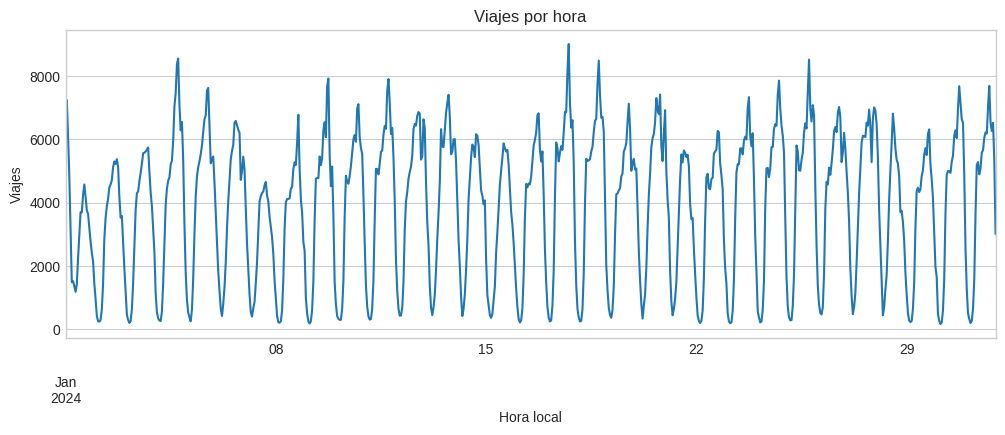

In [18]:
viajes_por_hora = viajes_zonas.set_index("pickup_hora").resample("h").size()
ax = viajes_por_hora.plot(figsize=(12, 4), color="#1f77b4", linewidth=1.5)
ax.set(title="Viajes por hora", xlabel="Hora local", ylabel="Viajes")
plt.show()

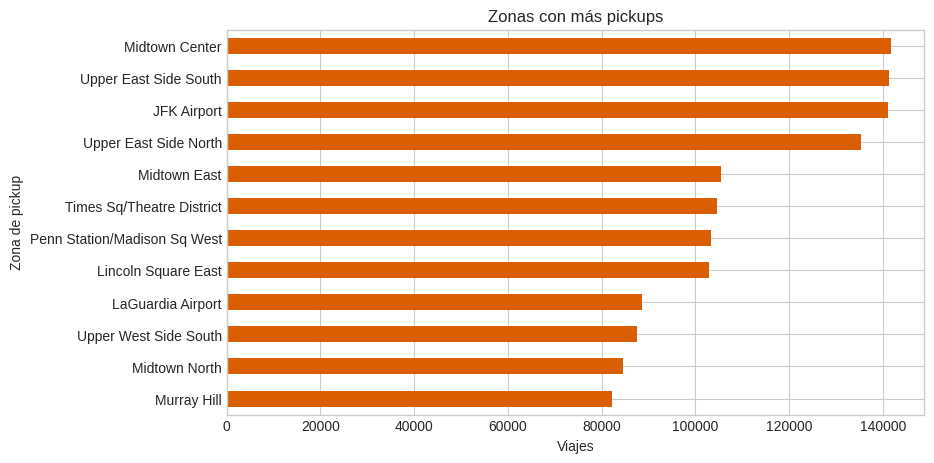

,pickups
pickup_zone,
Midtown Center,141714
Upper East Side South,141237
JFK Airport,141107
Upper East Side North,135303
Midtown East,105440
Times Sq/Theatre District,104590
Penn Station/Madison Sq West,103254
Lincoln Square East,102960
LaGuardia Airport,88556


In [19]:
top_zonas = viajes_zonas["pickup_zone"].value_counts().head(12).sort_values()
ax = top_zonas.plot.barh(figsize=(9, 5), color="#d95f02")
ax.set(title="Zonas con más pickups", xlabel="Viajes", ylabel="Zona de pickup")
plt.show()
display(top_zonas.sort_values(ascending=False).rename("pickups").to_frame())

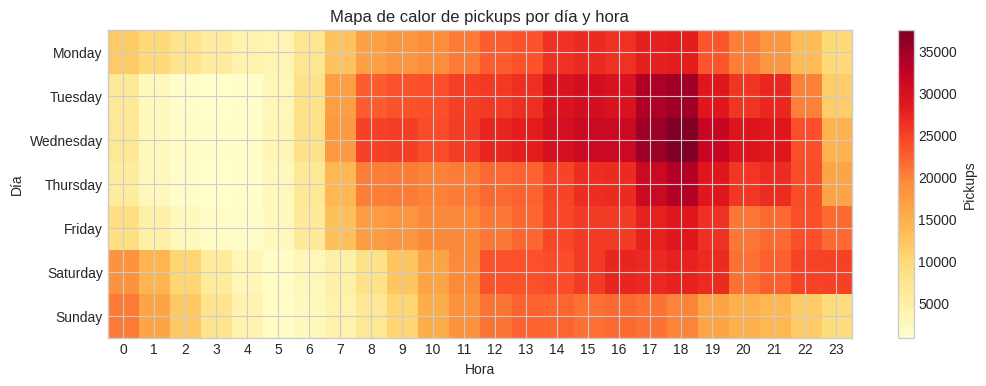

In [20]:
patron = viajes_zonas.assign(
    dia=viajes_zonas["pickup_hora"].dt.day_name(),
    hora_dia=viajes_zonas["pickup_hora"].dt.hour,
).pivot_table(index="dia", columns="hora_dia", values="PULocationID", aggfunc="size", fill_value=0)
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
patron = patron.reindex([d for d in orden_dias if d in patron.index])
fig, ax = plt.subplots(figsize=(12, 4))
imagen = ax.imshow(patron, aspect="auto", cmap="YlOrRd")
ax.set(title="Mapa de calor de pickups por día y hora", xlabel="Hora", ylabel="Día")
ax.set_xticks(range(24), labels=range(24))
ax.set_yticks(range(len(patron.index)), labels=patron.index)
fig.colorbar(imagen, ax=ax, label="Pickups")
plt.show()

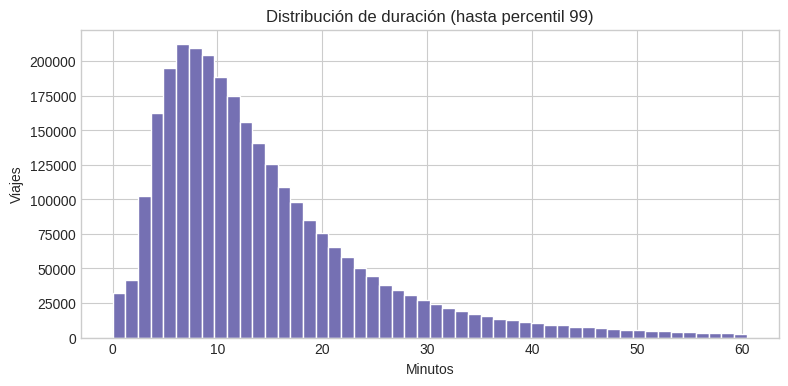

Percentil 99 mostrado: 60.5 minutos


In [21]:
limite_99 = viajes_validos["duracion_min"].quantile(0.99)
ax = viajes_validos.loc[viajes_validos["duracion_min"] <= limite_99, "duracion_min"].plot.hist(
    bins=50, figsize=(9, 4), color="#7570b3", edgecolor="white"
)
ax.set(title="Distribución de duración (hasta percentil 99)", xlabel="Minutos", ylabel="Viajes")
plt.show()
print("Percentil 99 mostrado:", round(limite_99, 1), "minutos")

### 9.1. De zona-hora a una observación por hora

Para comparar la actividad total de taxis con el clima debemos volver de la unidad **zona-hora** a la unidad **hora**. En el ejemplo anterior:

```text
pickups = 20 + 35 + 15 = 70
temperatura = 5 °C
```

Por eso usamos operaciones diferentes:

- `sum` para `pickups`, porque cada zona aporta viajes distintos;
- `first` para temperatura y precipitación, porque cada fila contiene una copia del mismo clima horario.

Sumar la temperatura produciría `5 + 5 + 5 = 15 °C`, un valor sin interpretación física. El uso de `first` requiere comprobar antes que una misma hora no contenga valores climáticos diferentes entre zonas.

Consistencia climática por hora: OK


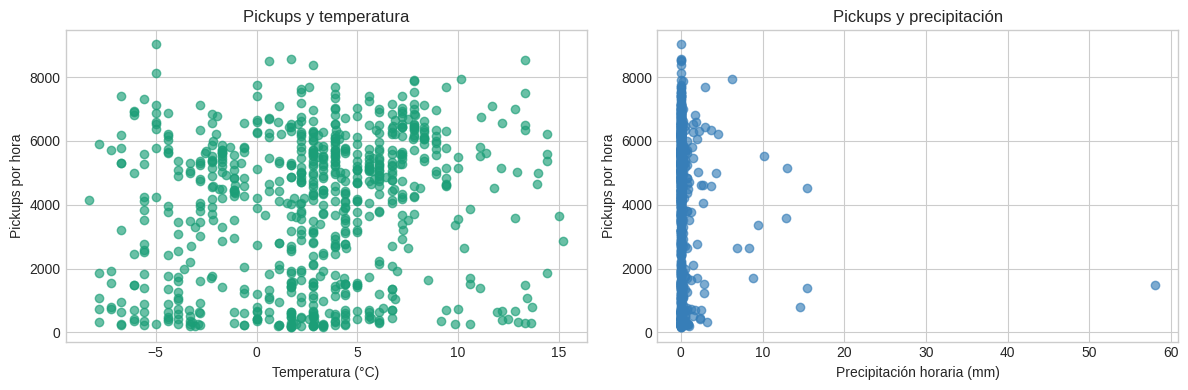

,pickups,temperatura_c,precipitacion_mm
pickups,1.000,0.158,-0.054
temperatura_c,0.158,1.000,0.193
precipitacion_mm,-0.054,0.193,1.000


In [22]:
# Verificamos el supuesto necesario para conservar una sola copia con 'first'.
variables_clima_repetidas = ["temperatura_c", "precipitacion_mm"]
consistencia_clima = (
    zona_hora_clima
    .groupby("pickup_hora")[variables_clima_repetidas]
    .nunique(dropna=False)
)
assert consistencia_clima.le(1).all().all(), (
    "Una misma hora contiene valores climáticos diferentes entre zonas"
)
print("Consistencia climática por hora: OK")

# El clima está repetido por zona; volvemos a una observación por hora.
comparacion_horaria = (
    zona_hora_clima.groupby("pickup_hora", as_index=False)
    .agg(
        pickups=("pickups", "sum"),
        temperatura_c=("temperatura_c", "first"),
        precipitacion_mm=("precipitacion_mm", "first"),
    )
)
assert not comparacion_horaria["pickup_hora"].duplicated().any()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(comparacion_horaria["temperatura_c"], comparacion_horaria["pickups"], alpha=0.65, color="#1b9e77")
axes[0].set(xlabel="Temperatura (°C)", ylabel="Pickups por hora", title="Pickups y temperatura")
axes[1].scatter(comparacion_horaria["precipitacion_mm"], comparacion_horaria["pickups"], alpha=0.65, color="#377eb8")
axes[1].set(xlabel="Precipitación horaria (mm)", ylabel="Pickups por hora", title="Pickups y precipitación")
plt.tight_layout()
plt.show()
display(comparacion_horaria[["pickups", "temperatura_c", "precipitacion_mm"]].corr().round(3))

### Pregunta breve

¿Qué ocurriría si sumáramos la temperatura después de haberla replicado por zona?

<details><summary>Ver respuesta orientativa</summary>La misma observación se contabilizaría varias veces y produciría una temperatura sin interpretación física. Los pickups sí se suman porque cada zona aporta viajes diferentes; el clima se conserva una sola vez porque es el mismo valor replicado.</details>

### Ejercicio 3: interpretar sin exagerar

Escribe dos observaciones de los gráficos y una explicación alternativa. Evita frases causales como “la lluvia provoca...”.

**Tu respuesta:**

1. ...
2. ...
3. Explicación alternativa: ...

<details><summary>Ver pauta de solución</summary>Una respuesta sólida identifica dirección, magnitud o franjas horarias, menciona la ventana analizada y reconoce factores de confusión como hora pico, día de semana, aeropuerto, feriados o disponibilidad de taxis. Una correlación horaria no permite atribuir causalidad al clima.</details>

## 10. Exportar el producto fuera del repositorio

Antes de exportar comprobamos la clave, ordenamos el producto y usamos el directorio temporal del sistema. El nombre distingue el modo de clase del mes completo para no declarar una cobertura que no fue procesada.

In [23]:
producto = zona_hora_clima.sort_values(["pickup_hora", "PULocationID"]).copy()
if producto.duplicated(["pickup_hora", "PULocationID"]).any():
    raise ValueError("La clave zona-hora no es única")

alcance = "primera_semana_enero_2024" if MODO_CLASE else "enero_2024"
ruta_producto = Path(tempfile.gettempdir()) / f"zona_hora_{alcance}.parquet"
producto.to_parquet(ruta_producto, index=False)
print("Producto temporal:", ruta_producto)
print("Unidad: zona de origen-hora local | Zona horaria:", ZONA_HORARIA)

Producto temporal: /tmp/zona_hora_enero_2024.parquet
Unidad: zona de origen-hora local | Zona horaria: America/New_York


#Trabajo práctico: exploración de dos variables

## Identificación del estudiante

**Nombre:** Erik Valencia Cardona  
**Curso:** Data Science  
**Trabajo:** Exploración de dos variables

## Par de columna seleccionado
- **CM-02:** temperatura_c | viento





##Vista analítica correspondiente
- Horaria | Una hora de enero | Pares que incluyen clima o pickups totales

## Declaración previa del análisis

| Campo | Respuesta |
|---|---|
| Código y par elegido | CM-02: temperatura_c \| viento |
| Pregunta exploratoria | ¿Cómo se relacionan la temperatura registrada y la velocidad del viento por hora durante enero de 2024 en Nueva York? |
| Significado de la primera columna | Temperatura del aire registrada por NOAA, expresada en grados Celsius. |
| Significado de la segunda columna | Velocidad del viento registrada por NOAA y resumida a nivel horario mediante el promedio de las observaciones disponibles. |
| Tipo semántico de cada columna | temperatura_c: numérica continua. viento: numérica continua. |
| Unidad analítica y vista | Una hora. Vista H — Horaria. |
| Periodo y zona horaria | Enero de 2024, desde 2024-01-01 00:00 hasta 2024-02-01 00:00, límite final excluido. Zona: America/New_York. |
| Población registrada | Horas registradas en la vista horaria durante enero de 2024. |
| Denominador o tamaño válido | Horas en las que temperatura_c y viento presentan simultáneamente valores válidos. |
| Afirmaciones que los datos no permiten | No permiten establecer causalidad ni generalizar los resultados a otros periodos, lugares o estaciones meteorológicas. |

In [24]:
variables_clima = [
    "temperatura_c",
    "humedad_relativa",
    "viento",
    "visibilidad"
]

consistencia_clima = (
    producto
    .groupby("pickup_hora")[variables_clima]
    .nunique(dropna=False)
)

display(consistencia_clima)

,temperatura_c,humedad_relativa,viento,visibilidad
pickup_hora,,,,
2024-01-01 00:00:00-05:00,1,1,1,1
2024-01-01 01:00:00-05:00,1,1,1,1
2024-01-01 02:00:00-05:00,1,1,1,1
2024-01-01 03:00:00-05:00,1,1,1,1
2024-01-01 04:00:00-05:00,1,1,1,1
...,...,...,...,...
2024-01-31 19:00:00-05:00,1,1,1,1
2024-01-31 20:00:00-05:00,1,1,1,1
2024-01-31 21:00:00-05:00,1,1,1,1


In [25]:
assert consistencia_clima.le(1).all().all(), (
    "Una misma hora contiene valores climáticos diferentes entre zonas"
)

print("Consistencia climática por hora: OK")

Consistencia climática por hora: OK


In [26]:
por_hora = (
    producto
    .groupby("pickup_hora", as_index=False)
    .agg(
        pickups=("pickups", "sum"),
        temperatura_c=("temperatura_c", "first"),
        humedad_relativa=("humedad_relativa", "first"),
        viento=("viento", "first"),
        visibilidad=("visibilidad", "first"),
    )
)

display(por_hora.head())

,pickup_hora,pickups,temperatura_c,humedad_relativa,viento,visibilidad
0,2024-01-01 00:00:00-05:00,6513,5.6,55.0,3.1,16.093
1,2024-01-01 01:00:00-05:00,7249,5.6,58.0,2.1,16.093
2,2024-01-01 02:00:00-05:00,6111,5.0,60.0,0.0,16.093
3,2024-01-01 03:00:00-05:00,4857,5.0,62.0,1.5,16.093
4,2024-01-01 04:00:00-05:00,3128,4.4,68.0,0.0,16.093


In [27]:
print("=== VALIDACIÓN DE LA VISTA H ===")

print("Filas de producto:", len(producto))
print("Filas de por_hora:", len(por_hora))

print("\n¿Horas duplicadas?")
print(por_hora["pickup_hora"].duplicated().any())

print("\nInicio:", por_hora["pickup_hora"].min())
print("Fin:", por_hora["pickup_hora"].max())

print("\nZona horaria:", por_hora["pickup_hora"].dt.tz)

print("\nHoras esperadas en enero:", 31 * 24)
print("Horas observadas:", len(por_hora))

=== VALIDACIÓN DE LA VISTA H ===
Filas de producto: 77466
Filas de por_hora: 744

¿Horas duplicadas?
False

Inicio: 2024-01-01 00:00:00-05:00
Fin: 2024-01-31 23:00:00-05:00

Zona horaria: America/New_York

Horas esperadas en enero: 744
Horas observadas: 744


# 1. Análisis univariado: temperatura_c

Se analiza la distribución de la temperatura registrada por hora durante enero de 2024. La unidad de análisis es una hora y la variable corresponde a la temperatura horaria obtenida de la estación meteorológica de NOAA.

In [28]:
temp = por_hora["temperatura_c"]

resumen_temp = pd.DataFrame({
    "total": [len(temp)],
    "validos": [temp.notna().sum()],
    "faltantes": [temp.isna().sum()],
    "porcentaje_faltantes": [temp.isna().mean() * 100],
    "media": [temp.mean()],
    "mediana": [temp.median()],
    "desv_std": [temp.std()],
    "minimo": [temp.min()],
    "Q1": [temp.quantile(0.25)],
    "Q3": [temp.quantile(0.75)],
    "maximo": [temp.max()]
})

display(resumen_temp)

,total,validos,faltantes,porcentaje_faltantes,media,mediana,desv_std,minimo,Q1,Q3,maximo
0,744,743,1,0.134409,2.735884,2.8,4.7627,-8.3,-0.6,6.1,15.2


##Valores unicos y ceros

In [29]:
print("Valores únicos:", temp.nunique(dropna=True))
print("Valores iguales a cero:", (temp == 0).sum())
print("Valores faltantes:", temp.isna().sum())

Valores únicos: 136
Valores iguales a cero: 18
Valores faltantes: 1


##Histograma

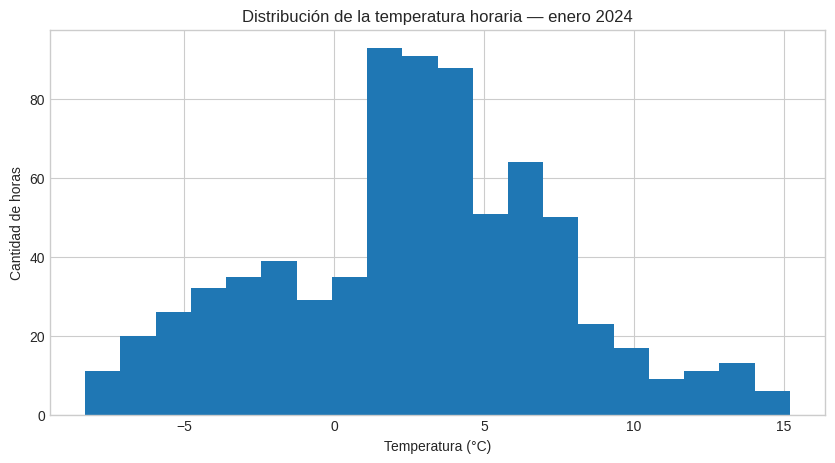

In [30]:
plt.figure(figsize=(10, 5))

plt.hist(temp.dropna(), bins=20)

plt.title("Distribución de la temperatura horaria — enero 2024")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Cantidad de horas")

plt.show()

**Interpretación:** El histograma permite observar cómo se distribuyen las temperaturas horarias registradas durante enero de 2024, identificando los intervalos de temperatura con mayor frecuencia y posibles valores extremos.

##Boxplot

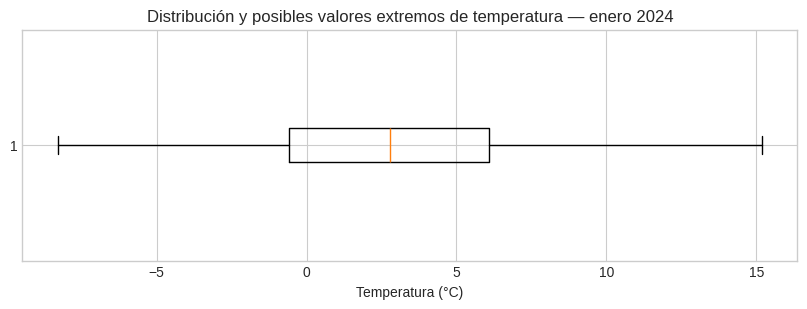

In [31]:
plt.figure(figsize=(10, 3))

plt.boxplot(temp.dropna(), vert=False)

plt.title("Distribución y posibles valores extremos de temperatura — enero 2024")
plt.xlabel("Temperatura (°C)")

plt.show()

# 2. Análisis univariado: viento

Se analiza la distribución de la velocidad del viento registrada por hora durante enero de 2024. Los valores horarios corresponden al promedio de las observaciones disponibles de la estación meteorológica.

In [32]:
viento = por_hora["viento"]

resumen_viento = pd.DataFrame({
    "total": [len(viento)],
    "validos": [viento.notna().sum()],
    "faltantes": [viento.isna().sum()],
    "porcentaje_faltantes": [viento.isna().mean() * 100],
    "media": [viento.mean()],
    "mediana": [viento.median()],
    "desv_std": [viento.std()],
    "minimo": [viento.min()],
    "Q1": [viento.quantile(0.25)],
    "Q3": [viento.quantile(0.75)],
    "maximo": [viento.max()]
})

display(resumen_viento)

,total,validos,faltantes,porcentaje_faltantes,media,mediana,desv_std,minimo,Q1,Q3,maximo
0,744,676,68,9.139785,2.992432,2.95,1.672655,0.0,2.1,4.1,9.266667


In [33]:
print("Valores únicos:", viento.nunique(dropna=True))
print("Valores iguales a cero:", (viento == 0).sum())
print("Valores faltantes:", viento.isna().sum())

Valores únicos: 84
Valores iguales a cero: 59
Valores faltantes: 68


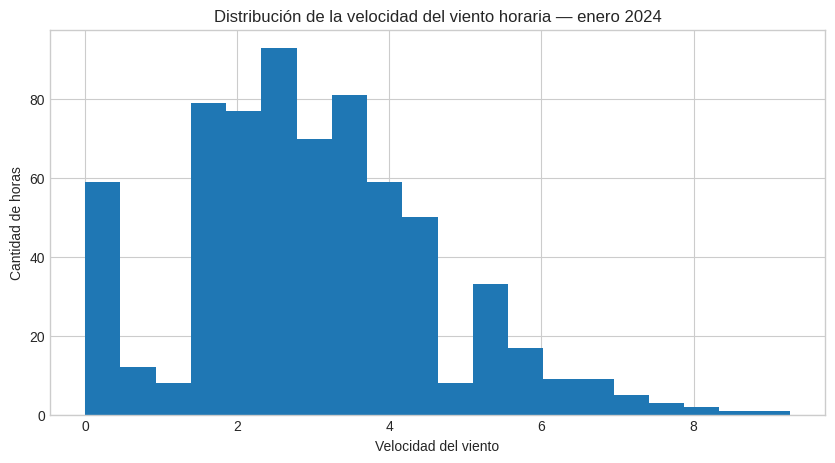

In [34]:
plt.figure(figsize=(10, 5))

plt.hist(viento.dropna(), bins=20)

plt.title("Distribución de la velocidad del viento horaria — enero 2024")
plt.xlabel("Velocidad del viento")
plt.ylabel("Cantidad de horas")

plt.show()

**Interpretación:** El histograma permite observar la distribución de las velocidades del viento registradas por hora, identificando los valores más frecuentes y posibles concentraciones o extremos.

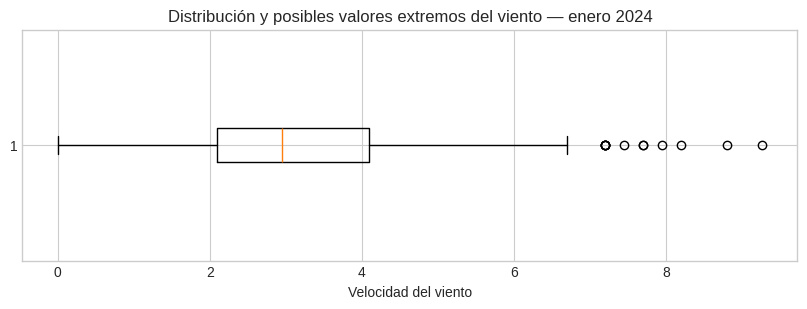

In [35]:
plt.figure(figsize=(10, 3))

plt.boxplot(viento.dropna(), vert=False)

plt.title("Distribución y posibles valores extremos del viento — enero 2024")
plt.xlabel("Velocidad del viento")

plt.show()

##Casos potencialmente anómalos

In [36]:
def detectar_anomalos_tukey(df, columna):
    datos = df[["pickup_hora", columna]].dropna().copy()

    q1 = datos[columna].quantile(0.25)
    q3 = datos[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    anomalos = datos[
        (datos[columna] < limite_inferior) |
        (datos[columna] > limite_superior)
    ].copy()

    anomalos["variable"] = columna
    anomalos["Q1"] = q1
    anomalos["Q3"] = q3
    anomalos["IQR"] = iqr
    anomalos["limite_inferior"] = limite_inferior
    anomalos["limite_superior"] = limite_superior

    return anomalos

In [37]:
anomalos_temp = detectar_anomalos_tukey(
    por_hora,
    "temperatura_c"
)

anomalos_viento = detectar_anomalos_tukey(
    por_hora,
    "viento"
)

anomalos = pd.concat(
    [anomalos_temp, anomalos_viento],
    ignore_index=True
)

display(anomalos)

,pickup_hora,temperatura_c,variable,Q1,Q3,IQR,limite_inferior,limite_superior,viento
0,2024-01-04 18:00:00-05:00,NaN,viento,2.1,4.1,2.0,-0.9,7.1,7.700000
1,2024-01-06 21:00:00-05:00,NaN,viento,2.1,4.1,2.0,-0.9,7.1,7.450000
2,2024-01-12 09:00:00-05:00,NaN,viento,2.1,4.1,2.0,-0.9,7.1,7.200000
3,2024-01-14 15:00:00-05:00,NaN,viento,2.1,4.1,2.0,-0.9,7.1,8.200000
4,2024-01-14 17:00:00-05:00,NaN,viento,2.1,4.1,2.0,-0.9,7.1,7.700000
5,2024-01-16 08:00:00-05:00,NaN,viento,2.1,4.1,2.0,-0.9,7.1,8.800000
6,2024-01-20 09:00:00-05:00,NaN,viento,2.1,4.1,2.0,-0.9,7.1,7.200000
7,2024-01-20 15:00:00-05:00,NaN,viento,2.1,4.1,2.0,-0.9,7.1,7.200000
8,2024-01-20 18:00:00-05:00,NaN,viento,2.1,4.1,2.0,-0.9,7.1,7.200000
9,2024-01-28 10:00:00-05:00,NaN,viento,2.1,4.1,2.0,-0.9,7.1,7.200000


In [38]:
print("Candidatos a anomalía en temperatura:",
      len(anomalos_temp))

print("Candidatos a anomalía en viento:",
      len(anomalos_viento))

Candidatos a anomalía en temperatura: 0
Candidatos a anomalía en viento: 12


## Regla para detectar casos potencialmente anómalos

Se utilizó la regla de Tukey para identificar valores candidatos a revisión. Se consideró potencialmente anómalo todo valor situado por debajo de Q1 − 1.5×IQR o por encima de Q3 + 1.5×IQR.

Estos casos no se consideran errores automáticamente. La regla solamente permite identificar observaciones que requieren una revisión adicional.

# 3. Análisis bivariado: temperatura_c y viento

Se analiza la asociación entre la temperatura horaria y la velocidad del viento utilizando únicamente las horas en las que ambas variables presentan valores válidos.

In [39]:
bivariado = por_hora[
    ["pickup_hora", "temperatura_c", "viento"]
].dropna()

print("Horas totales:", len(por_hora))
print("Horas válidas para el análisis bivariado:", len(bivariado))
print("Horas excluidas por faltantes:",
      len(por_hora) - len(bivariado))

Horas totales: 744
Horas válidas para el análisis bivariado: 676
Horas excluidas por faltantes: 68


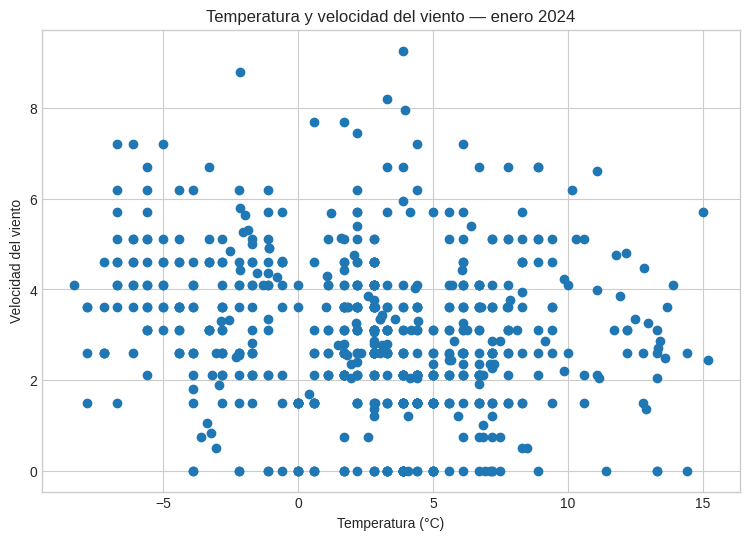

In [40]:
plt.figure(figsize=(9, 6))

plt.scatter(
    bivariado["temperatura_c"],
    bivariado["viento"]
)

plt.title("Temperatura y velocidad del viento — enero 2024")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Velocidad del viento")

plt.show()

**Interpretación:** El diagrama de dispersión permite observar la dirección, intensidad aproximada, forma y posibles agrupamientos de la relación entre temperatura y velocidad del viento. También permite identificar observaciones alejadas del conjunto principal.

##Correlación

In [41]:
pearson = bivariado["temperatura_c"].corr(
    bivariado["viento"],
    method="pearson"
)

spearman = bivariado["temperatura_c"].corr(
    bivariado["viento"],
    method="spearman"
)

print("Correlación de Pearson:", pearson)
print("Correlación de Spearman:", spearman)

Correlación de Pearson: -0.1701354351977306
Correlación de Spearman: -0.18378585375678186


##Evolución temporal

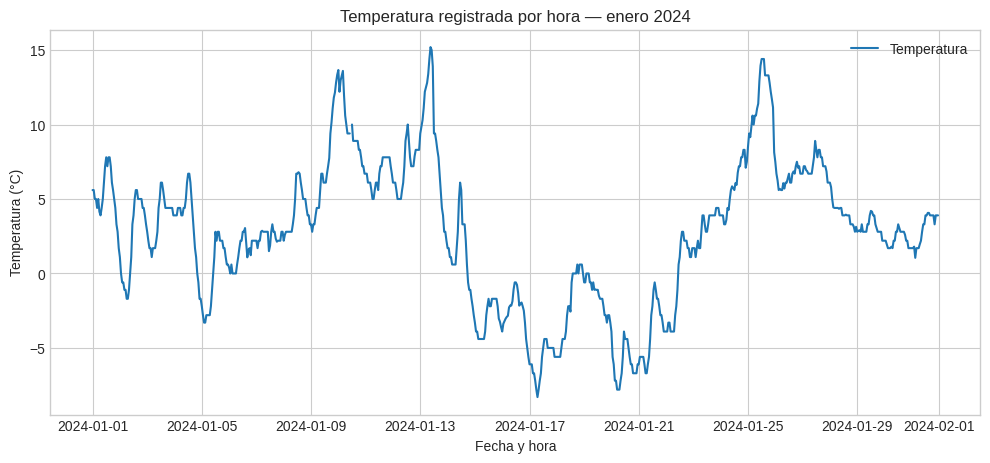

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(
    por_hora["pickup_hora"],
    por_hora["temperatura_c"],
    label="Temperatura"
)

plt.title("Temperatura registrada por hora — enero 2024")
plt.xlabel("Fecha y hora")
plt.ylabel("Temperatura (°C)")
plt.legend()

plt.show()

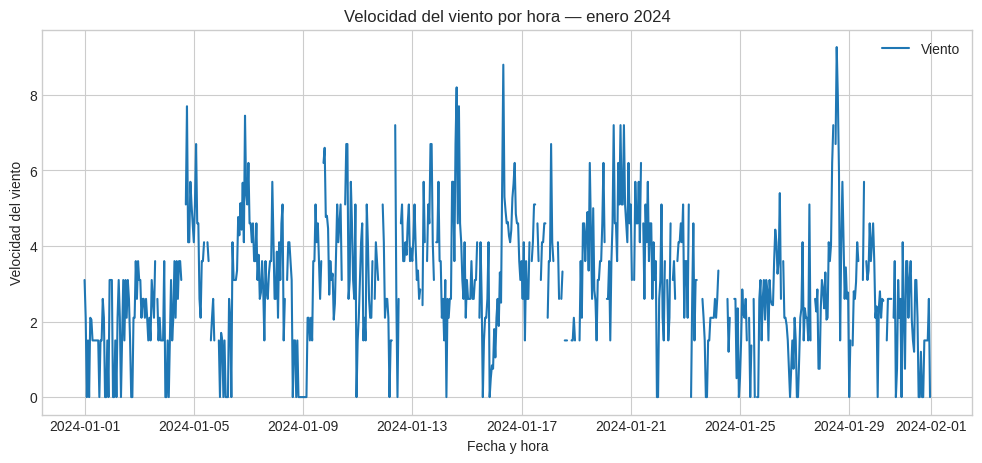

In [43]:
plt.figure(figsize=(12, 5))

plt.plot(
    por_hora["pickup_hora"],
    por_hora["viento"],
    label="Viento"
)

plt.title("Velocidad del viento por hora — enero 2024")
plt.xlabel("Fecha y hora")
plt.ylabel("Velocidad del viento")
plt.legend()

plt.show()

# 4. Análisis de sensibilidad

### Alternativa definida previamente

Como análisis de sensibilidad se comparará la asociación entre temperatura y viento utilizando:

1. Todos los registros horarios válidos.
2. Los mismos registros después de excluir los candidatos a anomalías identificados mediante la regla de Tukey.

La alternativa se define antes de comparar los resultados para evaluar cuánto depende la asociación observada de los valores extremos.

In [44]:
# Correlación original
corr_original = bivariado[
    ["temperatura_c", "viento"]
].corr(method="pearson").iloc[0, 1]

# Horas candidatas a anomalía en cualquiera de las dos variables
horas_anomalas = set(anomalos["pickup_hora"])

bivariado_sensibilidad = bivariado[
    ~bivariado["pickup_hora"].isin(horas_anomalas)
].copy()

corr_sensibilidad = bivariado_sensibilidad[
    ["temperatura_c", "viento"]
].corr(method="pearson").iloc[0, 1]

comparacion_sensibilidad = pd.DataFrame({
    "escenario": [
        "Todos los casos válidos",
        "Sin candidatos a anomalía"
    ],
    "n_horas": [
        len(bivariado),
        len(bivariado_sensibilidad)
    ],
    "correlacion_pearson": [
        corr_original,
        corr_sensibilidad
    ]
})

display(comparacion_sensibilidad)

,escenario,n_horas,correlacion_pearson
0,Todos los casos válidos,676,-0.170135
1,Sin candidatos a anomalía,664,-0.162117


In [45]:
cambio = corr_sensibilidad - corr_original

print("Cambio absoluto en Pearson:", cambio)

Cambio absoluto en Pearson: 0.008018489524719785


In [46]:
display(resumen_temp)
display(resumen_viento)

,total,validos,faltantes,porcentaje_faltantes,media,mediana,desv_std,minimo,Q1,Q3,maximo
0,744,743,1,0.134409,2.735884,2.8,4.7627,-8.3,-0.6,6.1,15.2


,total,validos,faltantes,porcentaje_faltantes,media,mediana,desv_std,minimo,Q1,Q3,maximo
0,744,676,68,9.139785,2.992432,2.95,1.672655,0.0,2.1,4.1,9.266667


# 5. Hallazgos finales

## Hallazgo 1 — Temperatura

Durante enero de 2024, la temperatura horaria registrada presentó una media de **2,74 °C** y una mediana de **2,80 °C**, con una desviación estándar de **4,76 °C**. Los valores observados variaron entre **-8,3 °C y 15,2 °C**, con el 50 % central de las observaciones comprendido entre **-0,6 °C (Q1)** y **6,1 °C (Q3)**. El análisis se basa en **743 horas válidas de las 744 horas registradas**, debido a un valor faltante. La regla de Tukey no identificó candidatos a anomalía para esta variable.

## Hallazgo 2 — Viento

Durante enero de 2024, la velocidad del viento horaria presentó una media de **2,99** y una mediana de **2,95**, con una desviación estándar de **1,67**. Los valores observados variaron entre **0,0 y 9,27**, mientras que el 50 % central de las observaciones se ubicó entre **2,1 (Q1)** y **4,1 (Q3)**. El análisis se basa en **676 horas válidas de las 744 horas registradas**, ya que se identificaron **68 valores faltantes**. La regla de Tukey identificó **12 observaciones como candidatas a anomalía**. Estos casos no se consideran errores automáticamente, sino observaciones que requieren una posible revisión adicional.

## Hallazgo 3 — Relación entre temperatura y viento

Entre las horas con valores válidos para ambas variables se observa una **asociación negativa débil** entre la temperatura y la velocidad del viento, con una correlación de **Pearson de -0,170**. La correlación de **Spearman fue de -0,184**, consistente con una asociación negativa de baja intensidad. El análisis se basa en **676 horas válidas de las 744 horas registradas**, mientras que 68 horas fueron excluidas debido a valores faltantes.

El análisis de sensibilidad mostró que, al excluir los candidatos a anomalía identificados mediante la regla de Tukey, la correlación de Pearson presentó un cambio absoluto de aproximadamente **0,008 puntos** respecto al valor original. Por lo tanto, la asociación observada presenta poca variación ante la exclusión de estos casos. Estos resultados describen una asociación observada en los registros de enero de 2024 y **no permiten establecer una relación causal**.

# 6. Límites y próximos pasos

## Límites

- El análisis es observacional y descriptivo, por lo que una asociación entre temperatura y viento no permite establecer causalidad.
- El periodo estudiado corresponde únicamente a enero de 2024, por lo que los resultados no deben generalizarse automáticamente a otros meses o estaciones.
- Las variables meteorológicas proceden de una única estación de NOAA, por lo que el análisis representa las condiciones registradas por esa estación y no necesariamente las condiciones meteorológicas de cada zona de Nueva York.
- Los valores climáticos se resumen a nivel horario; por lo tanto, se pierde información sobre variaciones dentro de cada hora.
- Los valores faltantes se mantienen como faltantes y las horas utilizadas en la relación bivariada corresponden únicamente a aquellas con valores válidos para ambas variables.
- Los casos identificados mediante Tukey son candidatos a revisión y no errores confirmados.
- La asociación observada puede estar influida por otros factores temporales o meteorológicos que no se controlan en este análisis.

## Próximos pasos

Como siguiente comprobación sería conveniente ampliar el análisis a varios meses y utilizar información meteorológica de más estaciones para evaluar la estabilidad espacial y temporal de la asociación. También podría incorporarse el día de la semana, la hora del día y otras variables meteorológicas para estudiar posibles factores de confusión.